Preparacion

In [3]:
import pandas as pd
import numpy as np
import os

In [4]:
DATA_PATH = "../data"

mapping_path = os.path.join(DATA_PATH, "gz2_filename_mapping.csv")
labels_path = os.path.join(DATA_PATH, "gz2_hart16.csv")

In [5]:
mapping_df = pd.read_csv(mapping_path)
labels_df = pd.read_csv(labels_path)

In [6]:
print("Mapping shape:", mapping_df.shape)
print("Labels shape:", labels_df.shape)

Mapping shape: (355990, 3)
Labels shape: (239695, 231)


In [7]:
mapping_df.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


In [19]:
labels_df.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [12]:
print(labels_df.columns.tolist())

['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_d

In [13]:
print("objid in mapping:", "objid" in mapping_df.columns)
print("objid in labels:", "objid" in labels_df.columns)

objid in mapping: True
objid in labels: False


In [17]:
merged_df = pd.merge(
    mapping_df,
    labels_df,
    left_on="objid",
    right_on="dr7objid",
    how="inner"
)

print("Merged shape:", merged_df.shape)

Merged shape: (239695, 234)


In [20]:
merged_df.head()

,objid,sample_x,asset_id,dr7objid,ra,dec,rastring,decstring,sample_y,gz2_class,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587722981741363294,original,3,587722981741363294,182.925262,-1.092357,12:11:42.06,-01:05:32.5,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
1,587722981741363323,original,4,587722981741363323,182.970108,-1.219537,12:11:52.83,-01:13:10.3,original,Sc?l,...,0.0,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1
2,587722981741559888,original,5,587722981741559888,183.438095,-1.238414,12:13:45.14,-01:14:18.3,original,Er,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
3,587722981741625481,original,6,587722981741625481,183.473999,-1.231429,12:13:53.76,-01:13:53.1,original,Sc1t,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
4,587722981741625484,original,7,587722981741625484,183.477783,-1.084604,12:13:54.67,-01:05:04.6,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


In [ ]:
[col for col in merged_df.columns if "smooth" in col]

['t01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't01_smooth_or_features_a03_star_or_artifact_flag',
 'smooth']

In [28]:
[col for col in merged_df.columns if "features" in col]

['t01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't01_smooth_or_features_a03_star_or_artifact_flag',
 'features']

In [30]:
merged_df["smooth"] = merged_df["t01_smooth_or_features_a01_smooth_debiased"]
merged_df["features"] = merged_df["t01_smooth_or_features_a02_features_or_disk_debiased"]

In [47]:
merged_df["label"] = np.where(
    merged_df["features"] > merged_df["smooth"],
    "spiral",
    "elliptical"
)

In [32]:
merged_df["label"].value_counts()

label
spiral        141809
elliptical     97886
Name: count, dtype: int64

In [33]:
threshold = 0.6

filtered_df = merged_df[
    (merged_df["smooth"] > threshold) |
    (merged_df["features"] > threshold)
]

In [34]:
filtered_df["label"].value_counts()
print("Filtered shape:", filtered_df.shape)

Filtered shape: (209278, 237)


In [49]:
IMAGE_DIR = "../data/images_gz2/images"

filtered_df["image_path"] = filtered_df["asset_id"].apply(
    lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg")
)

In [36]:
filtered_df[["asset_id", "image_path", "label"]].head()

,asset_id,image_path,label
0,3,../data/images_gz2\3.jpg,spiral
1,4,../data/images_gz2\4.jpg,spiral
2,5,../data/images_gz2\5.jpg,elliptical
3,6,../data/images_gz2\6.jpg,spiral
4,7,../data/images_gz2\7.jpg,spiral


In [50]:
import os

test_path = "../data/images_gz2/images"
print(test_path)
print(os.path.exists(test_path))

../data/images_gz2/images
True


In [51]:
filtered_df["image_path"].apply(os.path.exists).value_counts()

image_path
True     209225
False        53
Name: count, dtype: int64

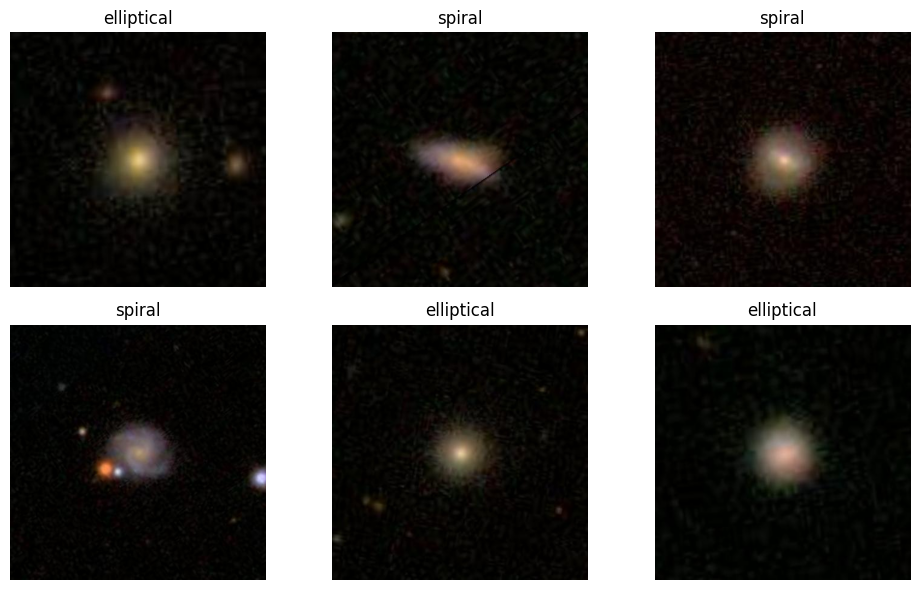

In [52]:
# visualización
import matplotlib.pyplot as plt
from PIL import Image

sample = filtered_df.sample(6)

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

Modelado 

Entrenamiento

Evaluación

Interpretacion

Conclusiones